# Create an elastic network for 7tx0 (mac1, p43 space group) and find its band structure

Goal: create a real enm and construct its Hessian & band structure

Code mostly lifted from proto-hessian.ipynb and 7tx0-enm.ipynb

Steps:

1. Use Mac1 P43 + ADPr [7TX0](https://www.rcsb.org/structure/7TX0), with two copies in the ASU. Group atoms by chain ID.
2. Pack the unit cell
3. Construct the contact list for the ASU. Keep only contacts between groups (or with other ASUs). Label springs by symmetry class indexed by w.
4. Expand to fill unit cell and add node positions
5. Delete duplicate springs due to double-counted inter-unit cell springs.
6. Create function which builds K taking diag({kLw,kTw}) as inputs. Somehow FFT to find K(q) and D(q).
7. Plot band structure along special directions. Following the TET path in [Setyawan and Curtarolo](https://arxiv.org/pdf/1004.2974), plot Γ-X-M-Γ-Z-R-A-Z|X-R|M-A.
8. Plot DOS from band structure.

In [1]:
#I will use gemmi to parse the PDB file 7tx0.cif.
#I then want to go towards constructing a Hessian for the rigid body ENM with springs organized nicely in a dataframe.
from goodvibes import enm, dynamat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gemmi
import random
from scipy import sparse
from collections import defaultdict

# 1. Assign rigid groups

In [2]:
#A lot of these lines will be borrowed from sandbox/steve/proto-hessian.ipynb

# !cd test_data && curl -O https://files.rcsb.org/download/7TX0.cif

coordinate_file = 'test_data/7TX0.cif'

st = gemmi.read_structure(coordinate_file)
st.setup_entities()  # supposed to be good practice

print('Unit Cell:',st.cell.parameters)
print('Space Group:',st.spacegroup_hm)

groups = [
    gemmi.Selection('//A;polymer'),
    gemmi.Selection('//B;polymer'),
]

tls_groups = []

# calculate the group center of mass, store as TLS group origin
for group_id, selection in enumerate(groups):
    model = selection.copy_model_selection(st[0])
    com = model.calculate_center_of_mass()
    g = gemmi.TlsGroup()
    g.id = f"TLS{group_id}"  # why is this a string? why can't I access num_id property?
    g.origin = com
    tls_groups.append(g)

st.meta.refinement[0].tls_groups = tls_groups

for group_id, selection in enumerate(groups):
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    atom.tls_group_id = group_id

Unit Cell: (88.451, 88.451, 39.823, 90.0, 90.0, 90.0)
Space Group: P 43


# 2. and 3. Pack unit cell and construct contact list. Label symmetry classes.

In [3]:
enm._pack_unit_cell(st, inplace=True)

df = enm._find_contacts(
   st,
   distance_cutoff=4.0,
   include_h=False,
)

def address_from_cra_string(cra):
    chain, residue, atom = cra.split('/')
    resname, seqid = residue.split()
    if '.' in atom:
        atom, altloc = atom.split('.')
    else:
        altloc = '\x00'
    addr =  gemmi.AtomAddress(chain, gemmi.SeqId(seqid), resname, atom, altloc)
    return addr

df['group_id1'] = -1
df['group_id2'] = -1

# add group ID columns to dataframe
for row in df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    df.at[row.Index, 'group_id1'] = cra1.atom.tls_group_id
    df.at[row.Index, 'group_id2'] = cra2.atom.tls_group_id

df['external'] = False

# add a column that indicates whether the contact is external (between different groups)
for row in df.itertuples():
    if row.group_id1 == -1 or row.group_id2 == -1:
        df.at[row.Index, 'external'] = False
    elif (row.sym_idx1 == row.sym_idx2) and (row.pbc_shift1 == row.pbc_shift2):
        # same ASU, check if the two residues have the same flag (i.e. belong to the same rigid group)
        df.at[row.Index, 'external'] = (row.group_id1 != row.group_id2)
    else:
        # different ASU, any group flag (not null)
        df.at[row.Index, 'external'] = True

# create a new dataframe that contains only the external contacts, dropping the 'external' column, reset index.
external_df = df[df['external']].drop(columns=['external']).reset_index(drop=True)
external_df

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
...,...,...,...,...,...,...,...,...
612,B/LEU 169/CD1,B/ASP 22/OD1,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
613,B/LEU 169/CD1,B/ASP 22/OD2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
614,B/LEU 169/CD2,B/ILE 23/CG2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
615,B/LEU 169/CD2,B/ALA 52/CB,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1


# 4. Expand to fill unit cell and add node positions

In [4]:
external_df_expanded = enm._symmetry_expand(external_df, st.cell.images)
external_df_expanded = external_df_expanded.rename(columns={'index': 'spring_class'})

def transform_position(st, sym_idx, pbc_shift, pos):
    if sym_idx == 0:
        image_transform = gemmi.Transform()
    else:
        image_transform = st.cell.images[sym_idx - 1]
    pbc_transform = gemmi.Transform(gemmi.Mat33(), gemmi.Vec3(*pbc_shift))
    t = pbc_transform @ image_transform
    return st.cell.orthogonalize(gemmi.Fractional(t.apply(st.cell.fractionalize(pos))))

external_df_expanded['r1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['r2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    pos1 = transform_position(st, row.sym_idx1, row.pbc_shift1, cra1.atom.pos)
    pos2 = transform_position(st, row.sym_idx2, row.pbc_shift2, cra2.atom.pos)
    external_df_expanded.at[row.Index, 'r1'] = (pos1.x, pos1.y, pos1.z)
    external_df_expanded.at[row.Index, 'r2'] = (pos2.x, pos2.y, pos2.z)

external_df_expanded

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.53765, 35.06444, 13.83823)","(33.5479, 38.297419999999995, 15.76611)"
4,4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(32.68961, 35.29065, 14.70957)","(34.09091, 38.94922, 14.69258)"
...,...,...,...,...,...,...,...,...,...,...,...
2208,612,B/LEU 169/CD1,B/ASP 22/OD1,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(17.4578, 79.14677999999999, -7.70419)"
2209,613,B/LEU 169/CD1,B/ASP 22/OD2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(15.84539, 77.71637999999999, -7.72701)"
2210,614,B/LEU 169/CD2,B/ILE 23/CG2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(19.34131, 83.05068999999999, -5.65706)"
2211,615,B/LEU 169/CD2,B/ALA 52/CB,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(18.87069, 78.58950999999999, -1.90476)"


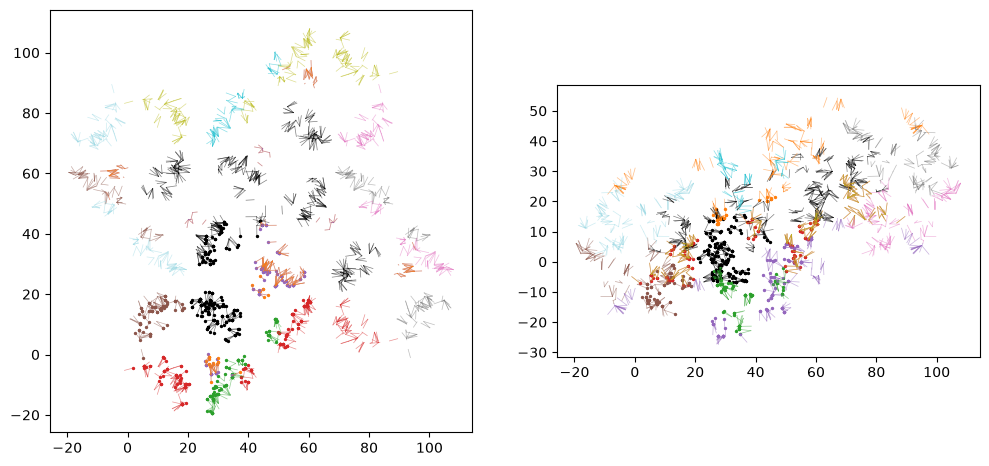

In [5]:
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.colormaps['tab20'].resampled(len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1.plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2.plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
    if row.sym_idx1 == 0:
        ax1.scatter(x1, y1, color=color, s=2)
        ax2.scatter(x1, z1, color=color, s=2)
    if (row.pbc_shift2 == (0, 0, 0)) and (row.sym_idx2 == 0):
        ax1.scatter(x2, y2, color=color, s=2)
        ax2.scatter(x2, z2, color=color, s=2)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

# 5. Delete duplicate springs due to PBC

In [6]:
# How to handle PBC? I think with current expanded model, the springs between unit cells will be double-counted.
# Can detect this, I think, by dropping the pbc_shift columns and finding unique edges.

external_df_expanded_pbc = external_df_expanded.copy()

#Sort based on cra and sym_idx
for row in external_df_expanded.itertuples():
    if (row.cra1, row.sym_idx1) > (row.cra2, row.sym_idx2):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1

external_df_expanded_pbc.drop_duplicates(subset=['cra1','cra2','sym_idx1','sym_idx2'],inplace=True)
external_df_expanded_pbc.reset_index(drop=True,inplace=True)

#swap sites 1 and 2 again so that cra1 is back inside the unit cell.
for row in external_df_expanded_pbc.itertuples():
    if row.pbc_shift1!=(0,0,0):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1
external_df_expanded_pbc

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...,...
1395,382,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,383,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,384,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,385,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


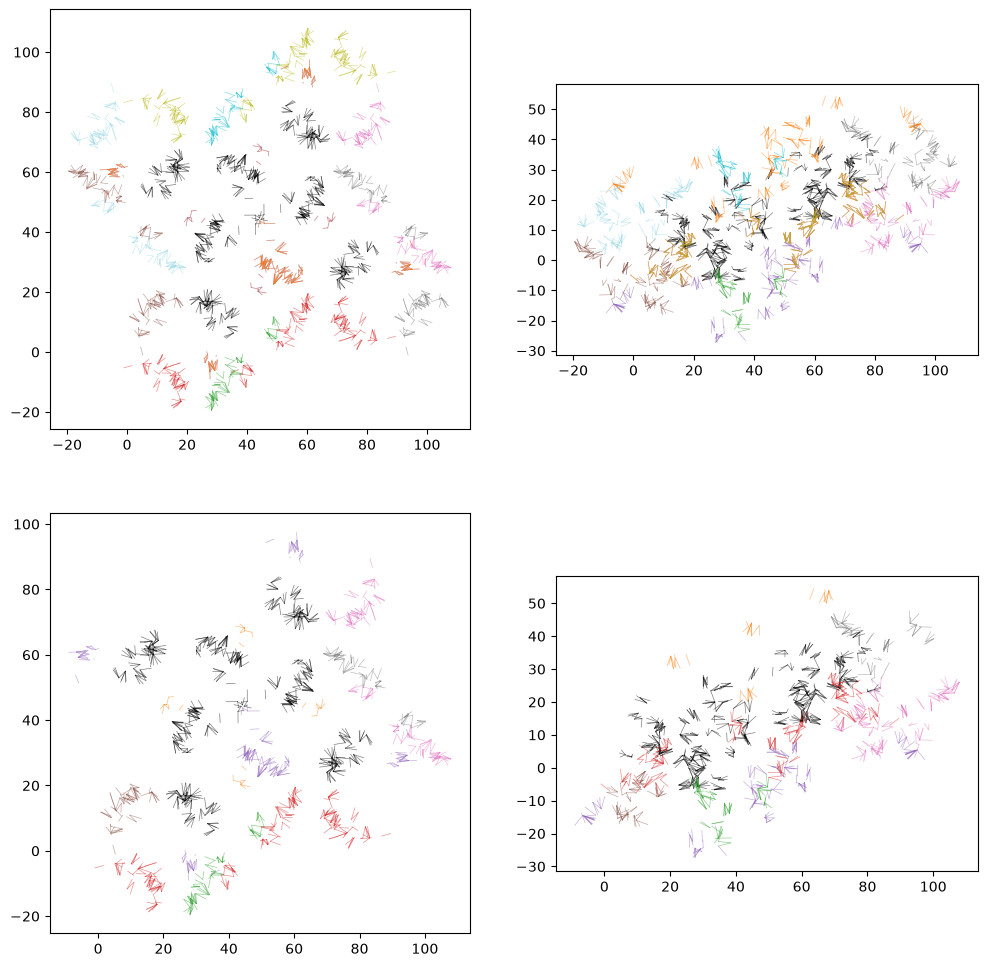

In [7]:
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(12, 12))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.colormaps['tab20'].resampled(len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1[0].plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax1[1].plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)

for row in external_df_expanded_pbc.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax2[0].plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2[1].plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
# equal aspect
ax1[0].set_aspect('equal', 'box')
ax1[1].set_aspect('equal', 'box')
ax2[0].set_aspect('equal', 'box')
ax2[1].set_aspect('equal', 'box')

In [8]:
#sanity check on number of bonds:
#for unit cell with double counting, N1 = N_intra + 2*N_inter.
#for unit cell without double counting, N2 = N_intra + N_inter.
N_intra1 = len(external_df_expanded.loc[external_df_expanded['pbc_shift2']==(0,0,0)])
N_intra2 = len(external_df_expanded_pbc.loc[external_df_expanded_pbc['pbc_shift2']==(0,0,0)])
#make sure we have the same number of intra-springs.
print(N_intra1==N_intra2)
#make sure we have half the original number of inter-springs.
N_inter1 = len(external_df_expanded)-N_intra1
N_inter2 = len(external_df_expanded_pbc)-N_intra2
print(N_inter1==2*N_inter2)

True
True


In [9]:
df_symmetry = external_df_expanded_pbc.copy()
#delete columns: cra1 is always in unit cell, n1, n2 extraneous for now.
df_symmetry = df_symmetry.drop(columns = ['pbc_shift1'])
#rename column: pbc_shift is the vector pointing from the unit cell of cra1 to the unit cell of cra2.
df_symmetry = df_symmetry.rename(columns={'pbc_shift2':'pbc_shift'})
df_symmetry

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1395,382,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,383,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,384,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,385,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


In [10]:
df_symmetry.sort_values(by=['spring_class'])

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1285,615,B/LEU 169/CD2,B/ALA 52/CB,2,3,"(1, 0, 0)",1,1,"(81.20943, 71.41976, 6.329090000000002)","(78.58950999999999, 69.58031, 8.05099)"
1017,615,B/LEU 169/CD2,B/ALA 52/CB,1,2,"(0, -1, 0)",1,1,"(71.41976, 7.24157, 16.284840000000003)","(69.58031, 9.86149, 18.00674)"
586,616,B/LEU 169/OXT,B/PHE 156/CB,0,1,"(-1, 0, -1)",1,1,"(3.92057, 13.5496, -12.55955)","(5.5451, 12.20417, -15.91071)"
1286,616,B/LEU 169/OXT,B/PHE 156/CB,2,3,"(1, 0, 0)",1,1,"(84.53043, 74.9014, 7.35195)","(82.9059, 76.24683, 4.00079)"


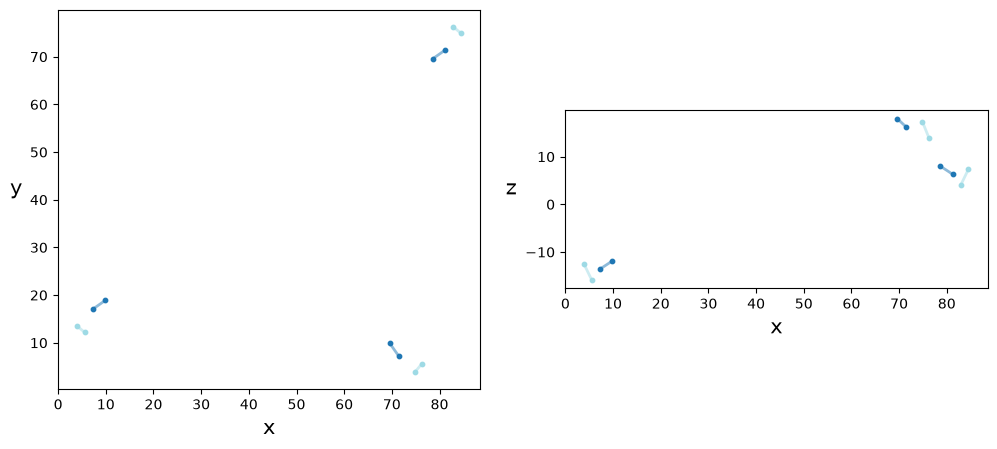

In [11]:
#sanity check - plot the bonds in the first symmetry class
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ws = [615,616]
colors = plt.colormaps['tab20'].resampled(len(ws))

for row in df_symmetry.itertuples():
    if row.spring_class not in ws:
         continue  # only plot contacts from certain symmetry classes
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    color = colors(list(ws).index(row.spring_class))
    ax1.plot([x1, x2], [y1, y2], alpha=0.5, linewidth=2, color=color)
    ax2.plot([x1, x2], [z1, z2], alpha=0.5, linewidth=2, color=color)
    ax1.scatter(x1, y1, color=color, s=10)
    ax1.scatter(x2, y2, color=color, s=10)
    ax2.scatter(x1, z1, color=color, s=10)
    ax2.scatter(x2, z2, color=color, s=10)
# labels
ax1.set_xlabel('x',fontsize=15)
ax1.set_ylabel('y',rotation=0,fontsize=15,labelpad=10)
ax2.set_xlabel('x',fontsize=15)
ax2.set_ylabel('z',rotation=0,fontsize=15,labelpad=10)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

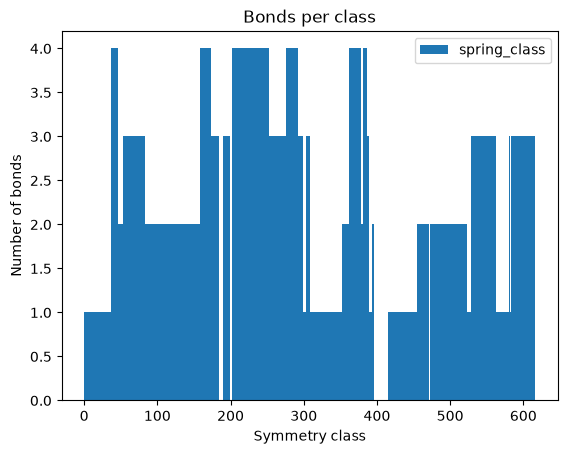

In [12]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['spring_class'],bins=617)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.show()

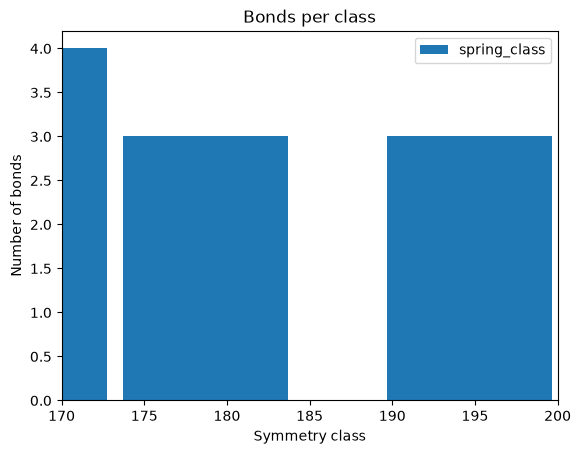

In [13]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['spring_class'],bins=617)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.xlim((170,200))
plt.show()

In [14]:
external_df.iloc[[185]]

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
185,A/LYS 102/O,A/LYS 31/CD.A,0,0,"(0, 0, 0)","(0, 0, -1)",0,0


In [15]:
external_df.iloc[[44]]

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
44,A/LYS 31/CD.A,A/LYS 102/O,0,0,"(0, 0, 0)","(0, 0, 1)",0,0


In [16]:
external_df_expanded.iloc[[185]]

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
185,185,A/LYS 102/O,A/LYS 31/CD.A,0,0,"(0, 0, 0)","(0, 0, -1)",0,0,"(43.69851, 20.18, -15.85842)","(45.04918000000001, 19.06019, -18.68401)"


In [17]:
external_df_expanded.iloc[[44]]

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
44,44,A/LYS 31/CD.A,A/LYS 102/O,0,0,"(0, 0, 0)","(0, 0, 1)",0,0,"(45.04918000000001, 19.06019, 21.13899)","(43.69851, 20.18, 23.96458)"


In [18]:
mapping = {x: i for i, x in enumerate(sorted(df_symmetry['spring_class'].unique()))}
df_symmetry['spring_class'] = df_symmetry['spring_class'].map(mapping)

In [19]:
df_symmetry.sort_values(by=['spring_class'])

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1285,585,B/LEU 169/CD2,B/ALA 52/CB,2,3,"(1, 0, 0)",1,1,"(81.20943, 71.41976, 6.329090000000002)","(78.58950999999999, 69.58031, 8.05099)"
1017,585,B/LEU 169/CD2,B/ALA 52/CB,1,2,"(0, -1, 0)",1,1,"(71.41976, 7.24157, 16.284840000000003)","(69.58031, 9.86149, 18.00674)"
586,586,B/LEU 169/OXT,B/PHE 156/CB,0,1,"(-1, 0, -1)",1,1,"(3.92057, 13.5496, -12.55955)","(5.5451, 12.20417, -15.91071)"
1286,586,B/LEU 169/OXT,B/PHE 156/CB,2,3,"(1, 0, 0)",1,1,"(84.53043, 74.9014, 7.35195)","(82.9059, 76.24683, 4.00079)"


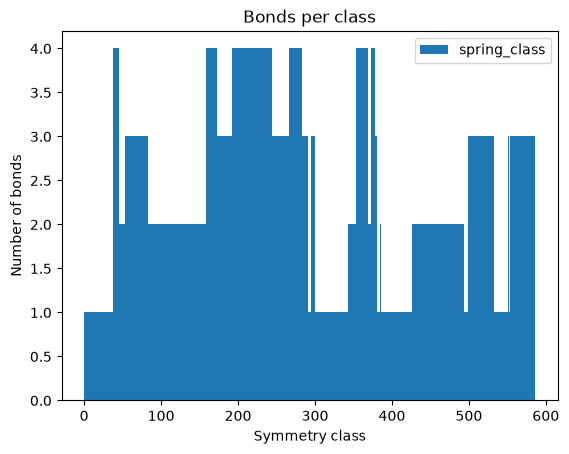

In [20]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['spring_class'],bins=587)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.show()

In [21]:
symm_classes = df_symmetry.sort_values(by=['spring_class']).iloc[[-1]]['spring_class'].tolist()[0]+1

In [22]:
symm_classes

587

In [23]:
df_symmetry

,spring_class,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1395,373,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,374,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,375,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,376,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


In [24]:
# ----------------------------------------------------------------------
# band path: Gamma-X-M-Gamma-Z-R-A-Z | X-R | M-A  (simple tetragonal, TET)
# ----------------------------------------------------------------------

HIGH_SYM_POINTS = {
    'G': np.array([0.0, 0.0, 0.0]),
    'X': np.array([0.5, 0.0, 0.0]),
    'M': np.array([0.5, 0.5, 0.0]),
    'Z': np.array([0.0, 0.0, 0.5]),
    'R': np.array([0.5, 0.0, 0.5]),
    'A': np.array([0.5, 0.5, 0.5]),
}
PATH_SEQ = ['G', 'X', 'M', 'G', 'Z', 'R', 'A', 'Z', '|', 'X', 'R', '|', 'M', 'A']

# 1. build df_atoms via space-group expansion
df_atoms = dynamat.build_df_atoms(st, groups)

# 2. rigid-body geometry: CM, generalized mass matrix, Cholesky
body_index, CM, L = dynamat.build_rigid_bodies(df_atoms)
M = len(body_index)
Linv = np.linalg.inv(L)

# 3. lattice / reciprocal lattice
lattice = dynamat.get_lattice(st.cell)
recip = dynamat.reciprocal_lattice(lattice)

# 4. df_symmetry already built elsewhere in pipeline
# df_symmetry = ...

sparse_L, sparse_T = dynamat.accumulate_sparse_blocks(df_symmetry, body_index, CM, lattice)

# 5. placeholder spring constants -- one per symmetry class, replace
#    with refined values
classes = sorted(df_symmetry['spring_class'].unique())
kL = {w: 1.0 for w in classes}
kT = {w: 0.5 for w in classes}

# 6. path, bands, plot
qs, xs, ticks, ticklabels, breaks = dynamat.build_path(recip, HIGH_SYM_POINTS, PATH_SEQ, n_per_segment=100)
bands = dynamat.compute_bands(qs, sparse_L, sparse_T, kL, kT, Linv, M)

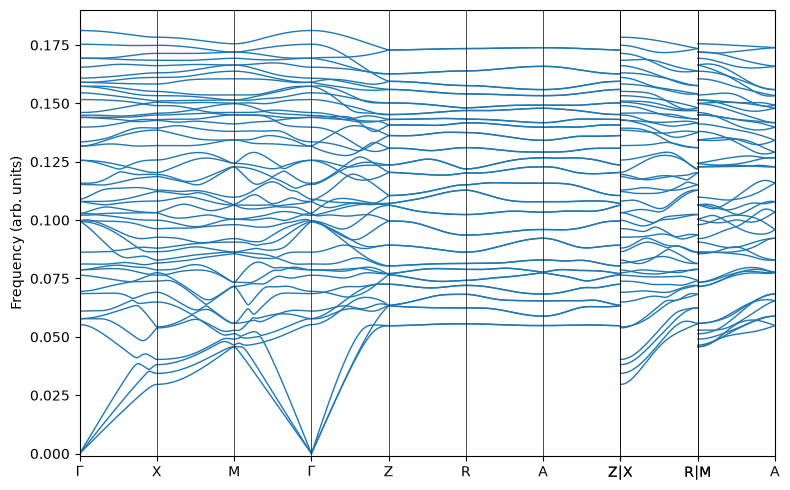

In [25]:
dynamat.plot_bands(bands, xs, ticks, ticklabels, -0.001, 0.19, breaks=breaks)

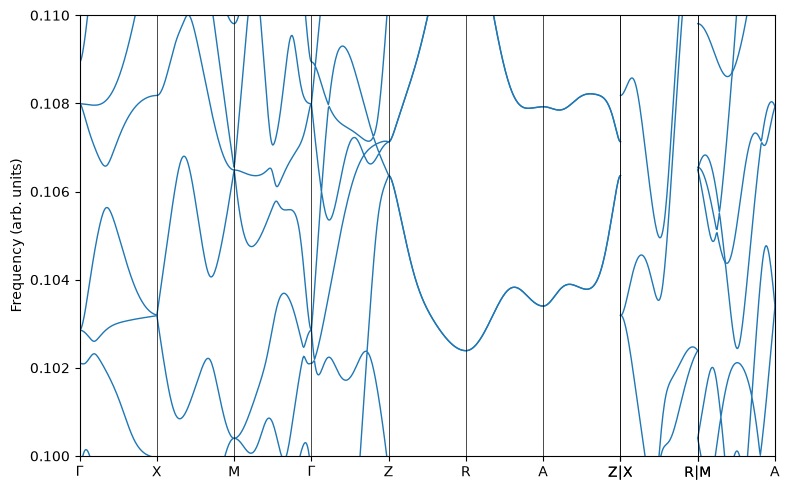

In [26]:
dynamat.plot_bands(bands, xs, ticks, ticklabels, 0.1, 0.11, breaks=breaks)